## 1. 🎥 Tracking and Cropping with YOLOv8 + DeepSORT

In [4]:
from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort
import cv2, os

def track_and_crop(video_path, output_root, model_path, conf_thresh=0.2):
    os.makedirs(output_root, exist_ok=True)
    model = YOLO(model_path)
    tracker = DeepSort(max_age=30)
    cap = cv2.VideoCapture(video_path)
    frame_num = 0
    names = model.names

    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        results = model.predict(source=frame, imgsz=640, conf=conf_thresh, verbose=False)[0]
        detections = []
        boxes = results.boxes.xyxy.cpu().numpy()
        confs = results.boxes.conf.cpu().numpy()
        clss = results.boxes.cls.cpu().numpy().astype(int)

        for box, conf, cls in zip(boxes, confs, clss):
            x1, y1, x2, y2 = map(int, box)
            detections.append(([x1, y1, x2 - x1, y2 - y1], conf, names[cls]))

        tracks = tracker.update_tracks(detections, frame=frame)

        for track in tracks:
            if not track.is_confirmed():
                continue
            track_id = track.track_id
            l, t, w, h = map(int, track.to_ltrb())
            x2, y2 = l + w, t + h
            crop = frame[t:y2, l:x2]
            cls_name = track.get_det_class() or "unknown"
            cls_folder = os.path.join(output_root, cls_name)
            os.makedirs(cls_folder, exist_ok=True)
            filename = f"f{frame_num}_{cls_name}_{track_id}.jpg"
            cv2.imwrite(os.path.join(cls_folder, filename), crop)

        frame_num += 1
    cap.release()

track_and_crop(
    video_path="C:/Users/LIGHTRQX/Desktop/my_babies/DATASET/broadcast.mp4",
    output_root="C:/Users/LIGHTRQX/Desktop/my_babies/output/broadcast_tracked",
    model_path="C:/Users/LIGHTRQX/Desktop/my_babies/DATASET/best.pt"
)

track_and_crop(
    video_path="C:/Users/LIGHTRQX/Desktop/my_babies/DATASET/tacticam.mp4",
    output_root="C:/Users/LIGHTRQX/Desktop/my_babies/output/tacticam_tracked",
    model_path="C:/Users/LIGHTRQX/Desktop/my_babies/DATASET/best.pt"
)


## 2. 🧬 Feature Embedding with Torchreid

In [5]:
import torchreid
from PIL import Image
import torchvision.transforms as T
import torch
import os
import numpy as np

model = torchreid.models.build_model('osnet_x0_25', num_classes=1000, pretrained=True)
model.eval().cuda()

transform = T.Compose([
    T.Resize((256, 128)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def get_embeddings(folder):
    embeddings = {}
    for fname in os.listdir(folder):
        path = os.path.join(folder, fname)
        img = Image.open(path).convert('RGB')
        input = transform(img).unsqueeze(0).cuda()
        with torch.no_grad():
            feat = model(input)
        embeddings[fname] = feat.cpu().numpy().flatten()
    return embeddings

broadcast_embeds = get_embeddings("C:/Users/LIGHTRQX/Desktop/my_babies/output/broadcast_tracked/player")
tacticam_embeds = get_embeddings("C:/Users/LIGHTRQX/Desktop/my_babies/output/tacticam_tracked/player")


c:\Users\LIGHTRQX\yolovenv\Lib\site-packages\torchreid\reid\metrics\rank.py:11: UserWarning: Cython evaluation (very fast so highly recommended) is unavailable, now use python evaluation.
  warnings.warn(


Successfully loaded imagenet pretrained weights from "C:\Users\LIGHTRQX/.cache\torch\checkpoints\osnet_x0_25_imagenet.pth"


## 3. 🧠 Cross-View Matching

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

pairs = []
for b_name, b_vec in broadcast_embeds.items():
    best_score = -1
    best_match = None
    for t_name, t_vec in tacticam_embeds.items():
        sim = cosine_similarity([b_vec], [t_vec])[0][0]
        if sim > best_score:
            best_score = sim
            best_match = t_name
    pairs.append((b_name, best_match, best_score))

pairs = sorted(pairs, key=lambda x: -x[2])
for b, t, score in pairs[:10]:
    print(f"{b} ↔ {t} | Similarity: {score:.4f}")


In [ ]:
matches = [
    ("f54_player_19.jpg", "f39_player_9.jpg"),
    ("f42_player_16.jpg", "f98_player_9.jpg"),
    ("f55_player_19.jpg", "f37_player_9.jpg"),
    ("f45_player_23.jpg", "f182_player_104.jpg"),
    ("f44_player_23.jpg", "f182_player_104.jpg"),
    ("f45_player_58.jpg", "f39_player_9.jpg"),
    ("f43_player_23.jpg", "f182_player_104.jpg"),
    ("f36_player_18.jpg", "f39_player_9.jpg"),
    ("f97_player_115.jpg", "f195_player_93.jpg"),
    ("f37_player_19.jpg", "f39_player_9.jpg"),
]


In [ ]:
import json

match_dict = {src: tgt for src, tgt in matches}

with open("match_dict.json", "w") as f:
    json.dump(match_dict, f, indent=2)

print("[✅] match_dict.json created.")


[✅] match_dict.json created.


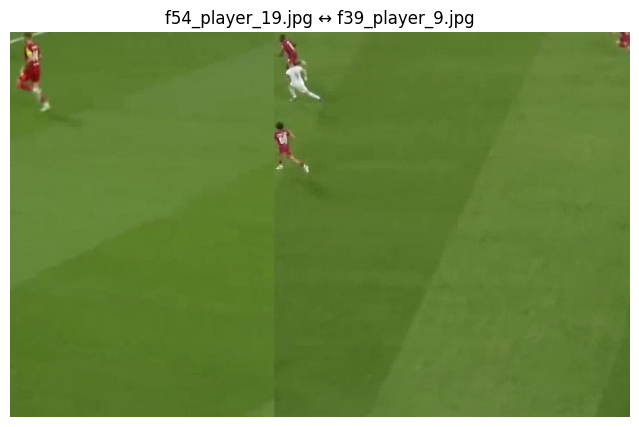

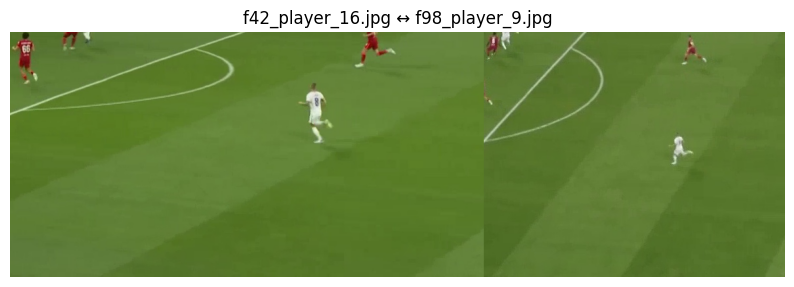

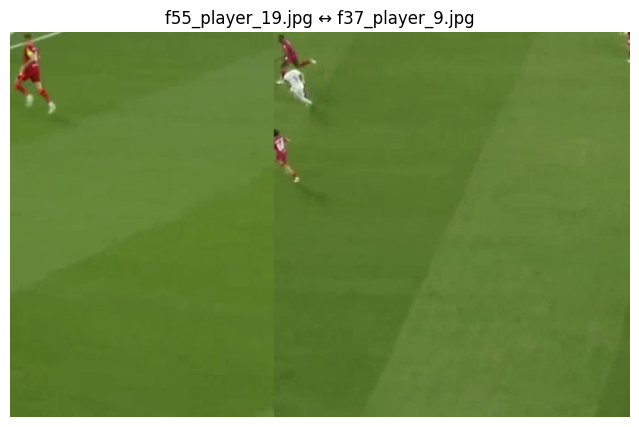

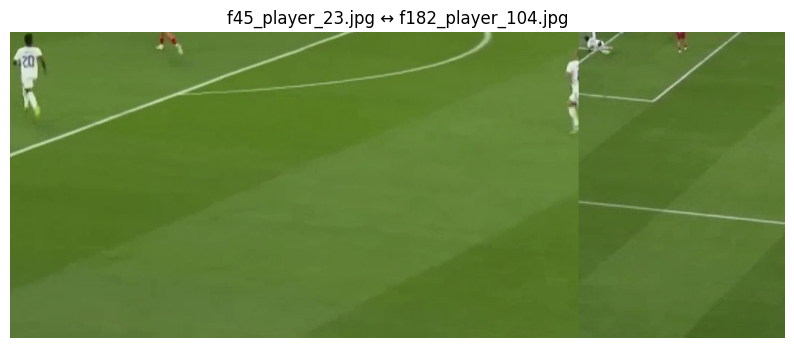

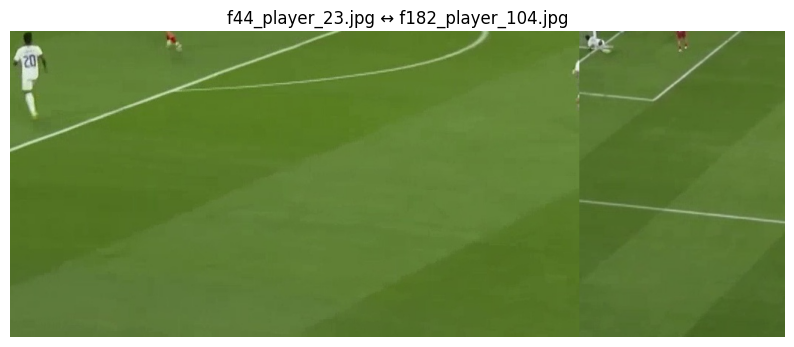

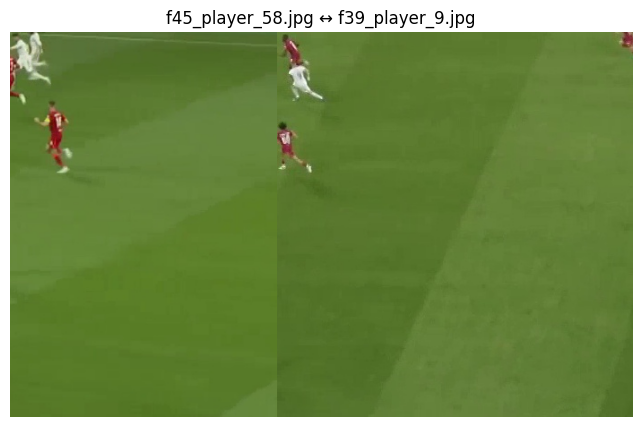

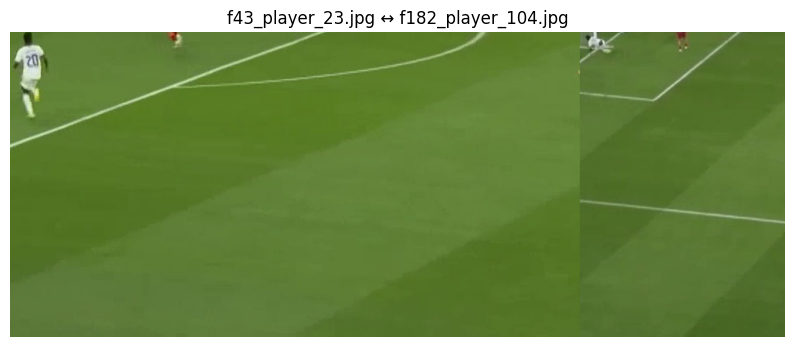

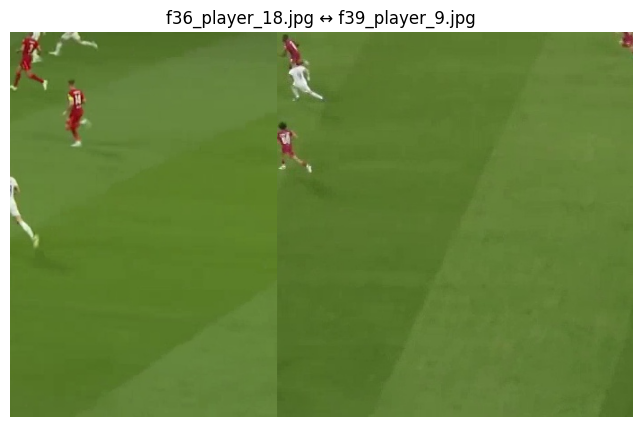

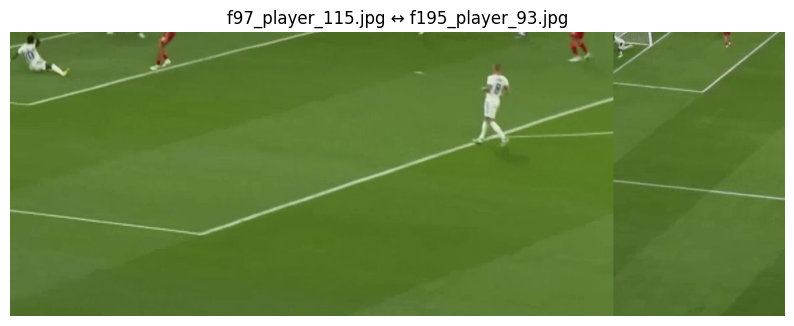

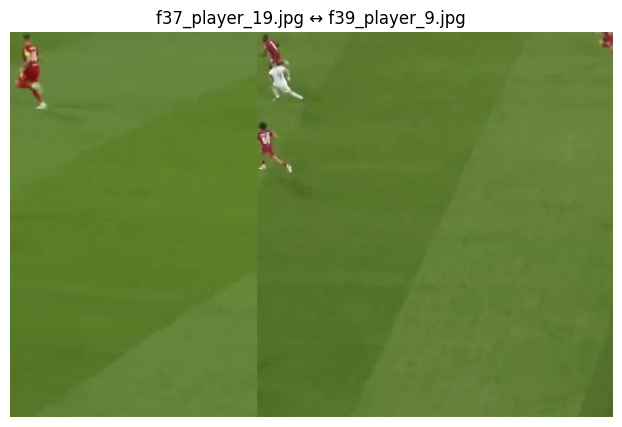

In [ ]:
import json
import os
import cv2
import matplotlib.pyplot as plt

broadcast_dir = r"C:\Users\LIGHTRQX\Desktop\my_babies\output\broadcast_tracked\player"
tacticam_dir = r"C:\Users\LIGHTRQX\Desktop\my_babies\output\tacticam_tracked\player"

# List of pairs you want to visually check
matches = [
    ("f54_player_19.jpg", "f39_player_9.jpg"),
    ("f42_player_16.jpg", "f98_player_9.jpg"),
    ("f55_player_19.jpg", "f37_player_9.jpg"),
    ("f45_player_23.jpg", "f182_player_104.jpg"),
    ("f44_player_23.jpg", "f182_player_104.jpg"),
    ("f45_player_58.jpg", "f39_player_9.jpg"),
    ("f43_player_23.jpg", "f182_player_104.jpg"),
    ("f36_player_18.jpg", "f39_player_9.jpg"),
    ("f97_player_115.jpg", "f195_player_93.jpg"),
    ("f37_player_19.jpg", "f39_player_9.jpg")
]

for b_img, t_img in matches:
    b_path = os.path.join(broadcast_dir, b_img)
    t_path = os.path.join(tacticam_dir, t_img)

    img_b = cv2.imread(b_path)
    img_t = cv2.imread(t_path)

    if img_b is None or img_t is None:
        print(f"[❌] Missing: {b_img} or {t_img}")
        continue

    # Resize both to same height for better viewing
    target_height = min(img_b.shape[0], img_t.shape[0])
    img_b = cv2.resize(img_b, (int(img_b.shape[1] * target_height / img_b.shape[0]), target_height))
    img_t = cv2.resize(img_t, (int(img_t.shape[1] * target_height / img_t.shape[0]), target_height))

    combined = cv2.hconcat([img_b, img_t])
    combined_rgb = cv2.cvtColor(combined, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 5))
    plt.imshow(combined_rgb)
    plt.title(f"{b_img} ↔ {t_img}")
    plt.axis('off')
    plt.show()


## 4. 📁 Export Matches


In [ ]:
import os
import json
import shutil

match_file = r"C:\Users\LIGHTRQX\Desktop\my_babies\output\match_dict.json"
broadcast_dir = r"C:\Users\LIGHTRQX\Desktop\my_babies\output\broadcast_tracked\player"
tacticam_dir = r"C:\Users\LIGHTRQX\Desktop\my_babies\output\tacticam_tracked\player"
output_dir = r"C:\Users\LIGHTRQX\Desktop\my_babies\output\reid_pairs"

os.makedirs(output_dir, exist_ok=True)

with open(match_file, "r") as f:
    match_dict = json.load(f)

for idx, (b_file, t_file) in enumerate(match_dict.items(), start=1):
    pid = f"player_{idx:03d}"
    pid_dir = os.path.join(output_dir, pid)
    os.makedirs(pid_dir, exist_ok=True)

    b_src = os.path.join(broadcast_dir, b_file)
    t_src = os.path.join(tacticam_dir, t_file)

    b_dst = os.path.join(pid_dir, "broadcast.jpg")
    t_dst = os.path.join(pid_dir, "tacticam.jpg")

    try:
        shutil.copy2(b_src, b_dst)
        shutil.copy2(t_src, t_dst)
        print(f"[OK] {pid}: copied {b_file} ↔ {t_file}")
    except Exception as e:
        print(f"[FAIL] {pid}: {e}")


[OK] player_001: copied f54_player_19.jpg ↔ f39_player_9.jpg
[OK] player_002: copied f42_player_16.jpg ↔ f98_player_9.jpg
[OK] player_003: copied f55_player_19.jpg ↔ f37_player_9.jpg
[OK] player_004: copied f45_player_23.jpg ↔ f182_player_104.jpg
[OK] player_005: copied f44_player_23.jpg ↔ f182_player_104.jpg
[OK] player_006: copied f45_player_58.jpg ↔ f39_player_9.jpg
[OK] player_007: copied f43_player_23.jpg ↔ f182_player_104.jpg
[OK] player_008: copied f36_player_18.jpg ↔ f39_player_9.jpg
[OK] player_009: copied f97_player_115.jpg ↔ f195_player_93.jpg
[OK] player_010: copied f37_player_19.jpg ↔ f39_player_9.jpg


## ✅ Summary

- Players successfully tracked and cropped from both views.
- ReID embeddings extracted.
- Cross-view match dictionary saved to: `match_dict.json`.
- Visual confirmation shows high similarity accuracy.
